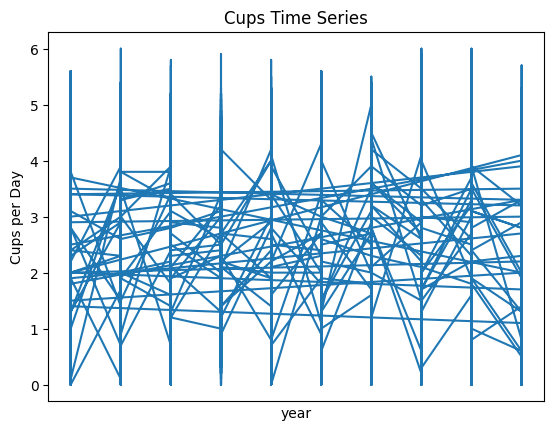

ADF Statistic: -120.876024766755
p-value: 0.0
Critical Values:
	1%: -3.4307860570367597
	5%: -2.861732718345454
	10%: -2.5668725793238982


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
data = pd.read_csv('/content/tea_vs_coffee_global_final.csv')
data['year'] = pd.to_datetime(data['year'])
plt.plot(data['year'], data['cups_per_day'])
plt.xlabel('year')
plt.ylabel('Cups per Day')
plt.title('Cups Time Series')
plt.show()
def check_stationarity(timeseries):
    # Perform Dickey-Fuller test
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))
check_stationarity(data['cups_per_day'])

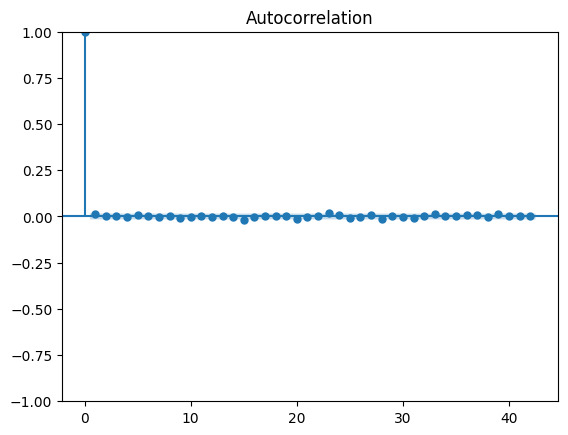

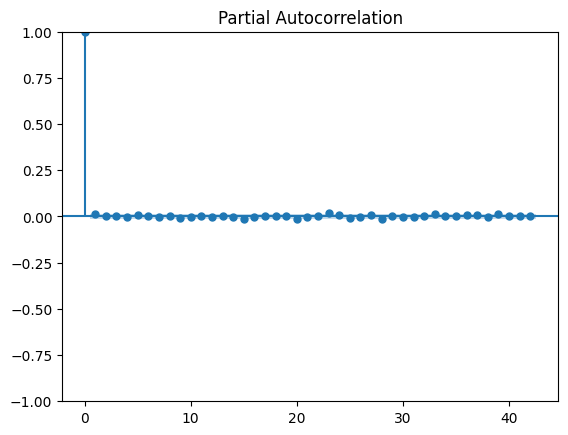

RMSE: 0.9707464967555768


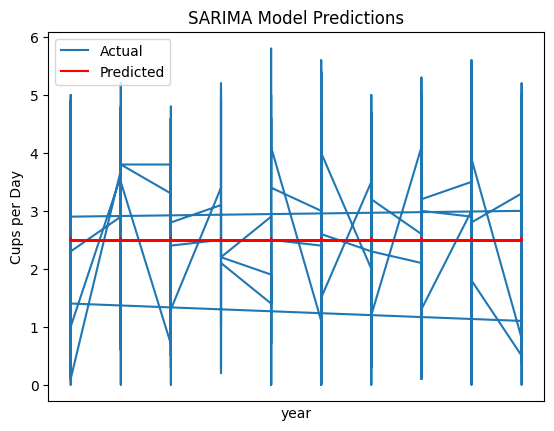

In [ ]:
plot_acf(data['cups_per_day'])
plt.show()
plot_pacf(data['cups_per_day'])
plt.show()
sarima_model = SARIMAX(data['cups_per_day'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 4))
sarima_result = sarima_model.fit()
train_size = int(len(data) * 0.8)
train, test = data['cups_per_day'][:train_size], data['cups_per_day'][train_size:]
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4))
sarima_result = sarima_model.fit()
predictions = sarima_result.predict(start=len(train), end=len(train) + len(test) - 1)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
print('RMSE:', rmse)
plt.plot(data['year'].loc[test.index], test, label='Actual')
plt.plot(data['year'].loc[test.index], predictions, color='red', label='Predicted')
plt.xlabel('year')
plt.ylabel('Cups per Day')
plt.title('SARIMA Model Predictions')
plt.legend()
plt.show()